In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем таблицу Excel
df = pd.read_excel('Данные_для_курсовои_Классическое_МО.xlsx')

# Посмотрим как выглядят данные
display(df.head())

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [2]:
# Выводим на экран размер датасета
print(f"Размер всего датасета: {df.shape}")

Размер всего датасета: (1001, 214)


In [3]:
# Выводим все названия столбцов построчно
for col in df.columns:
    print(col)

Unnamed: 0
IC50, mM
CC50, mM
SI
MaxAbsEStateIndex
MaxEStateIndex
MinAbsEStateIndex
MinEStateIndex
qed
SPS
MolWt
HeavyAtomMolWt
ExactMolWt
NumValenceElectrons
NumRadicalElectrons
MaxPartialCharge
MinPartialCharge
MaxAbsPartialCharge
MinAbsPartialCharge
FpDensityMorgan1
FpDensityMorgan2
FpDensityMorgan3
BCUT2D_MWHI
BCUT2D_MWLOW
BCUT2D_CHGHI
BCUT2D_CHGLO
BCUT2D_LOGPHI
BCUT2D_LOGPLOW
BCUT2D_MRHI
BCUT2D_MRLOW
AvgIpc
BalabanJ
BertzCT
Chi0
Chi0n
Chi0v
Chi1
Chi1n
Chi1v
Chi2n
Chi2v
Chi3n
Chi3v
Chi4n
Chi4v
HallKierAlpha
Ipc
Kappa1
Kappa2
Kappa3
LabuteASA
PEOE_VSA1
PEOE_VSA10
PEOE_VSA11
PEOE_VSA12
PEOE_VSA13
PEOE_VSA14
PEOE_VSA2
PEOE_VSA3
PEOE_VSA4
PEOE_VSA5
PEOE_VSA6
PEOE_VSA7
PEOE_VSA8
PEOE_VSA9
SMR_VSA1
SMR_VSA10
SMR_VSA2
SMR_VSA3
SMR_VSA4
SMR_VSA5
SMR_VSA6
SMR_VSA7
SMR_VSA8
SMR_VSA9
SlogP_VSA1
SlogP_VSA10
SlogP_VSA11
SlogP_VSA12
SlogP_VSA2
SlogP_VSA3
SlogP_VSA4
SlogP_VSA5
SlogP_VSA6
SlogP_VSA7
SlogP_VSA8
SlogP_VSA9
TPSA
EState_VSA1
EState_VSA10
EState_VSA11
EState_VSA2
EState_VSA3
EState_VSA4

In [4]:
# Проверяем типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [5]:
# Проверяем датасет на наличие пропущенных значений
total_nans = df.isnull().sum().sum()
print(f"Количество пропущенных значений в таблице: {total_nans}")

Количество пропущенных значений в таблице: 36


In [6]:
# Заполняем пропуски медианой по каждому столбцу
for col in df.columns:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [7]:
# Удаляем первую служебную колонку
df = df.drop(columns=['Unnamed: 0'])

# Проверяем данные
display(df.head())

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Считаем количество полных дубликатов
duplicates_count = df.duplicated().sum()
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 32


In [9]:
# Удаляем дубликаты строк
df = df.drop_duplicates()

In [10]:
# Собираем данные в памяти вместе
df = df.copy()

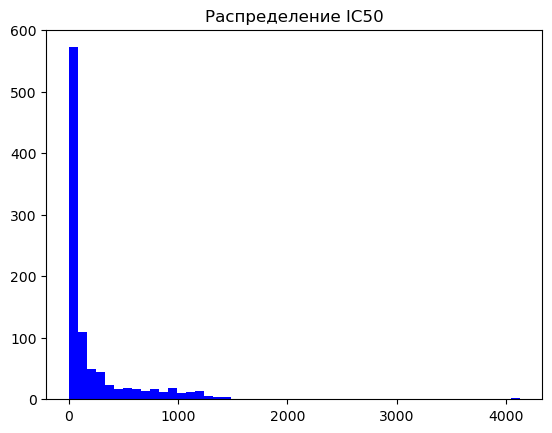

In [11]:
# График для IC50
plt.hist(df['IC50, mM'], bins=50, color='blue')
plt.title('Распределение IC50')
plt.show()

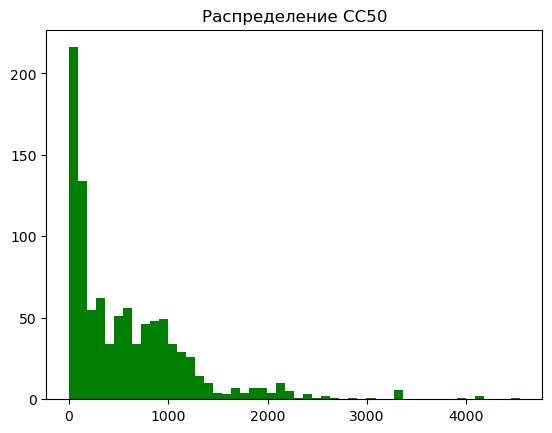

In [12]:
# График для CC50
plt.hist(df['CC50, mM'], bins=50, color='green')
plt.title('Распределение CC50')
plt.show()

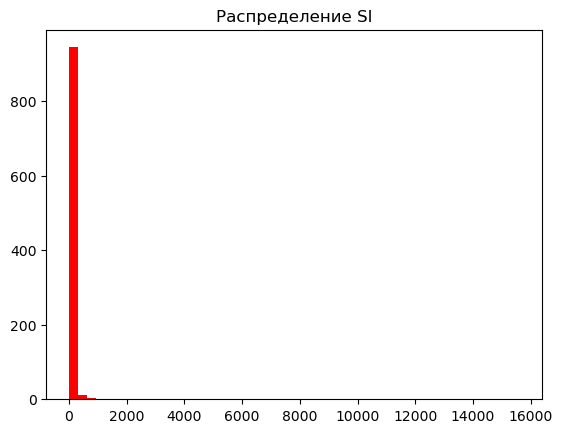

In [13]:
# График для SI
plt.hist(df['SI'], bins=50, color='red')
plt.title('Распределение SI')
plt.show()

In [14]:
# Для классификации переведем числовые значения в категории 0 и 1
# Для IC50: чем меньше доза, тем лучше препарат
median_ic50 = df['IC50, mM'].median()
df['IC50_class'] = (df['IC50, mM'] < median_ic50).astype(int)

# Для CC50 и SI: чем больше значение, тем безопаснее лекарство
median_cc50 = df['CC50, mM'].median()
df['CC50_class'] = (df['CC50, mM'] > median_cc50).astype(int)

median_si = df['SI'].median()
df['SI_median_class'] = (df['SI'] > median_si).astype(int)
df['SI_8_class'] = (df['SI'] > 8).astype(int)

На графиках выше видно, что данные имеют сильные "хвосты". Удалим аномалии по базовому параметру размера молекулы (MolWt) с помощью межквартильного размаха (IQR)

In [15]:
# Удаляем выбросы
Q1 = df['MolWt'].quantile(0.25)
Q3 = df['MolWt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Считаем размер до удаления
size_before = len(df)

# Оставляем только те строки, которые больше нижней границы и меньше верхней
df = df[df['MolWt'] >= lower_bound]
df = df[df['MolWt'] <= upper_bound]
df = df.reset_index(drop=True)

size_after = len(df)
print(f"Удалено выбросов по молекулярной массе: {size_before - size_after}")

Удалено выбросов по молекулярной массе: 39


В датасете много колонок химических фрагментов (fr_), где в основном нули. Чтобы снизить размерность, сгруппируем их по химическим свойствам

In [16]:
# Группируем их по химическим свойствам
groups = {
    'fr_aromatic': ['fr_benzene', 'fr_pyridine', 'fr_furan', 'fr_thiophene', 'fr_imidazole', 'fr_oxazole'],
    'fr_acidic': ['fr_COO', 'fr_Al_COO', 'fr_Ar_COO', 'fr_phos_acid'],
    'fr_basic': ['fr_aniline', 'fr_piperdine', 'fr_piperzine', 'fr_Imine'],
    'fr_hbd': ['fr_Al_OH', 'fr_Ar_OH', 'fr_NH0', 'fr_NH1', 'fr_NH2'],
    'fr_hba': ['fr_ether', 'fr_ester', 'fr_ketone', 'fr_amide', 'fr_nitrile'],
    'fr_halogen': ['fr_halogen', 'fr_alkyl_halide'],
    'fr_sulfur': ['fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_thiazole', 'fr_thiophene', 'fr_thiocyan']
}

# Складываем колонки
for group_name, group_cols in groups.items():
    existing_cols = []
    for col in group_cols:
        if col in df.columns:
            existing_cols.append(col)

    if len(existing_cols) > 0:
        df['sum_' + group_name] = df[existing_cols].sum(axis=1)

# Ищем колонки, которые начинаются на fr_
fr_cols_to_drop = []
for col in df.columns:
    if str(col).startswith('fr_'):
        fr_cols_to_drop.append(col)

# Удаляем первичные колонки fr_
df = df.drop(columns=fr_cols_to_drop)
print(f"Размер датасета после группировки фрагментов: {df.shape}")

Размер датасета после группировки фрагментов: (930, 139)


In [17]:
# Отделяем целевые переменные, чтобы избежать утечки данных
targets = ['IC50, mM', 'CC50, mM', 'SI', 'IC50_class', 'CC50_class', 'SI_median_class', 'SI_8_class']

# Собираем список признаков (не таргет)
features_cols = []
for col in df.columns:
    if col not in targets:
        features_cols.append(col)

features = df[features_cols]

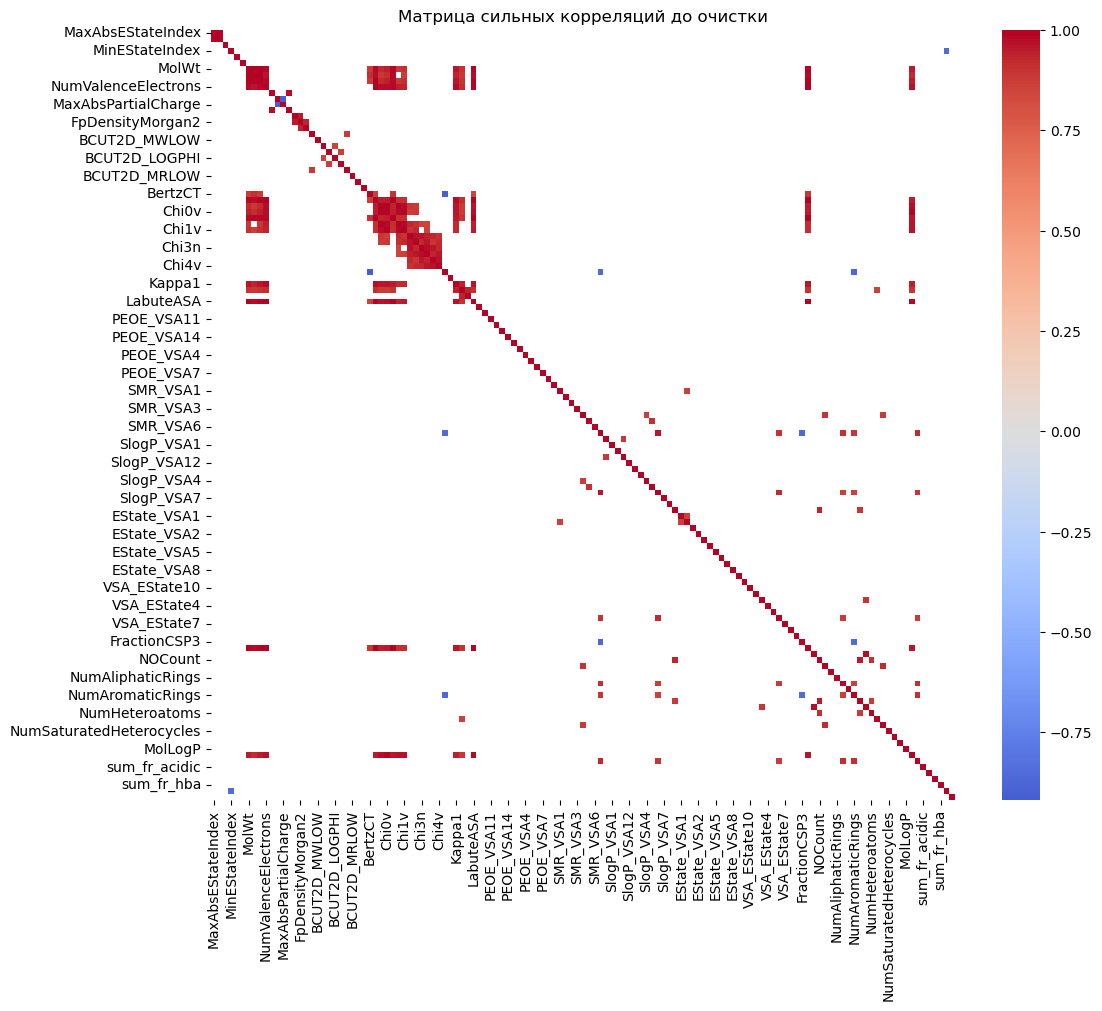

In [18]:
# Считаем матрицу корреляций
corr_matrix = features.corr(numeric_only=True)

# График до преобразований
corr_filtered_before = corr_matrix.copy()

# Прячем слабые связи (меньше 0.85 по модулю), заменяя их на пустоту
corr_filtered_before[abs(corr_filtered_before) < 0.85] = np.nan

# Удаляем пустые строки и столбцы
corr_filtered_before = corr_filtered_before.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_filtered_before, cmap="coolwarm", center=0)
plt.title('Матрица сильных корреляций до очистки')
plt.show()

In [19]:
# Ищем и удаляем дубликаты
to_drop = []
columns = corr_matrix.columns

# Перебираем матрицу по строкам и столбцам
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col1 = columns[i]
        col2 = columns[j]

        # Если корреляция сильная, добавляем колонку в список на удаление
        if abs(corr_matrix.loc[col1, col2]) > 0.85:
            if col2 not in to_drop:
                to_drop.append(col2)

print(f"Удалено признаков: {len(to_drop)}")

# Удаляем мусорные признаки из датасета
df_cleaned = df.drop(columns=to_drop)

Удалено признаков: 50


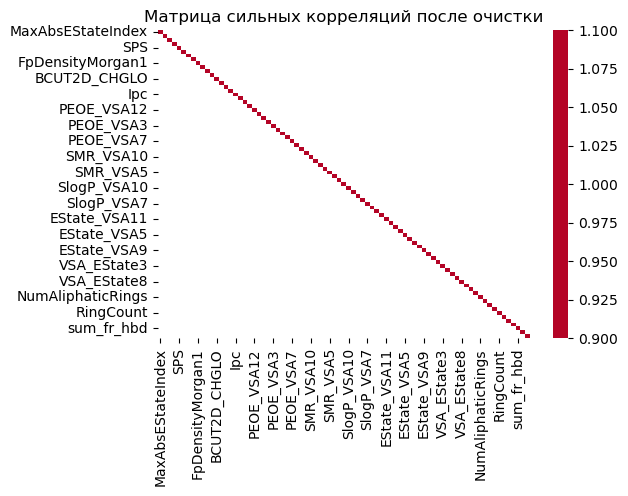

In [20]:
# График после преобразований
# Собираем новые признаки
features_cols_cleaned = []
for col in df_cleaned.columns:
    if col not in targets:
        features_cols_cleaned.append(col)

corr_matrix_cleaned = df_cleaned[features_cols_cleaned].corr(numeric_only=True)
corr_filtered_after = corr_matrix_cleaned.copy()
corr_filtered_after[abs(corr_filtered_after) < 0.85] = np.nan
corr_filtered_after = corr_filtered_after.dropna(how='all', axis=0).dropna(how='all', axis=1)

plt.figure(figsize=(6, 4))
if corr_filtered_after.empty:
    plt.text(0.5, 0.5, "Сильных корреляций больше нет", ha='center', va='center', fontsize=14)
    plt.axis('off')
else:
    sns.heatmap(corr_filtered_after, cmap="coolwarm", center=0)
plt.title('Матрица сильных корреляций после очистки')
plt.show()

In [21]:
print(f"Размер финального датасета: {df_cleaned.shape}")

Размер финального датасета: (930, 89)


In [22]:
# Сохраняем файл
df_cleaned.to_csv('cleaned_data.csv', index=False)